In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
from sklearn.preprocessing import power_transform
from scipy.stats import norm

# **Function 2** — Mystery ML Model
- I am working with a mystery black-box model that takes two numbers as input and returns a log-likelihood score. 

- My goal is to maximise that score on a noisy, multi-peaked surface.

- **Optimisation Goal**: Maximise

- **Input**: 2D array.

- **All-time best**: 0.590717 at [0.703106, 0.923905] (Week 9 breakthrough)

In [2]:
# Load current cumulative dataset (original + prior weekly updates) for Function 2
X = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy')
Y = np.load('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy')

# New data for Week 9 (Function 2)
X_w9_new_point = np.array([0.703106, 0.923905], dtype=np.float64)
Y_w9_new_point = np.array([0.5907174443680876], dtype=np.float64)

# Append the new data point
X_updated = np.vstack((X, X_w9_new_point.reshape(1, -1)))

# Remove duplicate X rows (if point already exists)
X_unique, unique_indices = np.unique(X_updated, axis=0, return_index=True)

# Build Y and keep matching rows only
Y_all = np.append(Y, Y_w9_new_point)
Y_updated = Y_all[unique_indices]

# Save updated arrays
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_inputs.npy', X_unique)
np.save('/Users/prathamyeole/Library/CloudStorage/OneDrive-Personal/Imperial - Machine Learning and Artifical Intelligence Certification/Capstone/Weekly Capstone Updates and Comments/Week 1/Initial_data_points_starter/initial_data/function_2/initial_outputs.npy', Y_updated)

# Show updated arrays
print("Updated Inputs (X) - Function 2: ", X_unique)
print("Updated Outputs (Y) - Function 2: ", Y_updated)

Updated Inputs (X) - Function 2:  [[0.14269907 0.34900513]
 [0.33864816 0.21386725]
 [0.34174959 0.02869772]
 [0.43816606 0.68501826]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.638512   0.01429   ]
 [0.656253   0.988919  ]
 [0.66579958 0.12396913]
 [0.688961   0.010598  ]
 [0.69697    0.070707  ]
 [0.70263656 0.9265642 ]
 [0.703106   0.923905  ]
 [0.730653   0.213258  ]
 [0.736899   0.001     ]
 [0.84527543 0.71112027]
 [0.871256   0.999348  ]
 [0.87779099 0.7786275 ]
 [0.998312   0.002851  ]]
Updated Outputs (Y) - Function 2:  [-0.06562362 -0.01385762  0.03874902  0.24461934  0.21496451  0.02310555
  0.29668333  0.51976639  0.53899612  0.55966119  0.49414992  0.61120522
  0.59071744  0.48809387  0.37180079  0.29399291  0.05410069  0.42058624
 -0.08088786]


## **Output Analysis**
- **Comparison**: Week 9 returned an output of 0.5907. 
    - This is our highest recorded value to date, surpassing the Week 4 peak of 0.560.

- **Real-world Implication**: By moving to the top-right of the search space, I have found a superior peak. 
    - This indicates that the function has a complex, multi-modal structure where the highest rewards are not necessarily where we first expected them to be.

- **Model/Future Exploration**: The Gaussian Process now has two competing high-value regions: the old Week 4 area and this new Week 9 summit. 
    - For Week 10, the model should pivot to exploit this new discovery. 
        - I will use a very tight search radius around these new coordinates to see if I am on the shoulder of the peak or the exact summit.

## **Bayesian Optimisation**

- **Changes**: I am using the Yeo-Johnson Output Transformation and a Matern 2.5 kernel with a refined length scale.

- **Reasoning**: Yeo-Johnson is essential for normalizing the log-likelihood output distribution.
    - I am setting the `length_scale` to 0.1 to allow the model to capture the sharp curvature of this new peak without over-smoothing the results based on distant, lower-value data points.

In [3]:
# Yeo-Johnson Output Transformation
Y_clipped = np.clip(Y_updated, -1e10, None)
Y_transformed = power_transform(Y_clipped.reshape(-1, 1), method='yeo-johnson').ravel()

# Kernel selection for local exploitation of the new peak
kernel = Matern(length_scale=0.1, length_scale_bounds=(1e-2, 1.0), nu=2.5) + \
         WhiteKernel(noise_level=1e-4)

model = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=25)
model.fit(X_unique, Y_transformed)

,"kernel kernel: kernel instance, default=NoneThe kernel specifying the covariance function of the GP. If None ispassed, the kernel ``ConstantKernel(1.0, constant_value_bounds=""fixed"")* RBF(1.0, length_scale_bounds=""fixed"")`` is used as default. Note thatthe kernel hyperparameters are optimized during fitting unless thebounds are marked as ""fixed"".",Matern(length..._level=0.0001)
,"alpha alpha: float or ndarray of shape (n_samples,), default=1e-10Value added to the diagonal of the kernel matrix during fitting.This can prevent a potential numerical issue during fitting, byensuring that the calculated values form a positive definite matrix.It can also be interpreted as the variance of additional Gaussianmeasurement noise on the training observations. Note that this isdifferent from using a `WhiteKernel`. If an array is passed, it musthave the same number of entries as the data used for fitting and isused as datapoint-dependent noise level. Allowing to specify thenoise level directly as a parameter is mainly for convenience andfor consistency with :class:`~sklearn.linear_model.Ridge`.For an example illustrating how the alpha parameter controlsthe noise variance in Gaussian Process Regression, see:ref:`sphx_glr_auto_examples_gaussian_process_plot_gpr_noisy_targets.py`.",1e-10
,"optimizer optimizer: ""fmin_l_bfgs_b"", callable or None, default=""fmin_l_bfgs_b""Can either be one of the internally supported optimizers for optimizingthe kernel's parameters, specified by a string, or an externallydefined optimizer passed as a callable. If a callable is passed, itmust have the signature:: def optimizer(obj_func, initial_theta, bounds): # * 'obj_func': the objective function to be minimized, which # takes the hyperparameters theta as a parameter and an # optional flag eval_gradient, which determines if the # gradient is returned additionally to the function value # * 'initial_theta': the initial value for theta, which can be # used by local optimizers # * 'bounds': the bounds on the values of theta .... # Returned are the best found hyperparameters theta and # the corresponding value of the target function. return theta_opt, func_minPer default, the L-BFGS-B algorithm from `scipy.optimize.minimize`is used. If None is passed, the kernel's parameters are kept fixed.Available internal optimizers are: `{'fmin_l_bfgs_b'}`.",'fmin_l_bfgs_b'
,"n_restarts_optimizer n_restarts_optimizer: int, default=0The number of restarts of the optimizer for finding the kernel'sparameters which maximize the log-marginal likelihood. The first runof the optimizer is performed from the kernel's initial parameters,the remaining ones (if any) from thetas sampled log-uniform randomlyfrom the space of allowed theta-values. If greater than 0, all boundsmust be finite. Note that `n_restarts_optimizer == 0` implies that onerun is performed.",25
,"normalize_y normalize_y: bool, default=FalseWhether or not to normalize the target values `y` by removing the meanand scaling to unit-variance. This is recommended for cases wherezero-mean, unit-variance priors are used. Note that, in thisimplementation, the normalisation is reversed before the GP predictionsare reported... versionchanged:: 0.23",False
,"copy_X_train copy_X_train: bool, default=TrueIf True, a persistent copy of the training data is stored in theobject. Otherwise, just a reference to the training data is stored,which might cause predictions to change if the data is modifiedexternally.",True
,"n_targets n_targets: int, default=NoneThe number of dimensions of the target values. Used to decide the numberof outputs when sampling from the prior distributions (i.e. calling:meth:`sample_y` before :meth:`fit`). This parameter is ignored once:meth:`fit` has been called... versionadded:: 1.3",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation used to initialize the centers.Pass an int for reproducible results across multiple function calls.See :term:`

## **Acquisition Function**

- **Type**: Expected Improvement (EI) with $\xi=0.001$.

- **Sample Size**: 10,000 points.Intended Impact and Reasoning: I am choosing Expected Improvement with a very low $\xi$ to prioritize exploitation.

- The intended impact is a micro-search. 
    - I am generating 90% of my candidates in a very small Gaussian cloud (standard deviation of 0.01) around the [0.703, 0.924] coordinates. 
    - This will force the acquisition function to look for the absolute highest point in the immediate vicinity of our breakthrough. 
    - The remaining 10% are uniform samples to maintain a baseline level of global awareness.

In [6]:
def expected_improvement(X, model, y_max, xi=0.001):
    mu, sigma = model.predict(X, return_std=True)
    mu, sigma = mu.reshape(-1, 1), sigma.reshape(-1, 1)

    with np.errstate(divide='warn'):
        improvement  = mu - y_max - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei

# Ultra-focused sampling around the new breakthrough
X_w9_best = X_w9_new_point
X_focused = np.random.normal(loc=X_w9_best, scale=0.01, size=(9000, 2))
X_uniform = np.random.uniform(0, 1, size=(1000, 2))
X_candidates = np.clip(np.vstack([X_focused, X_uniform]), 0, 1)

y_max_trans = np.max(Y_transformed)
ei_values = expected_improvement(X_candidates, model, y_max_trans)
next_query = X_candidates[np.argmax(ei_values)]

print(f"Next Query Point (F2): {next_query[0]:.6f}-{next_query[1]:.6f}")

Next Query Point (F2): 0.701022-0.958065


## **Visualisation**

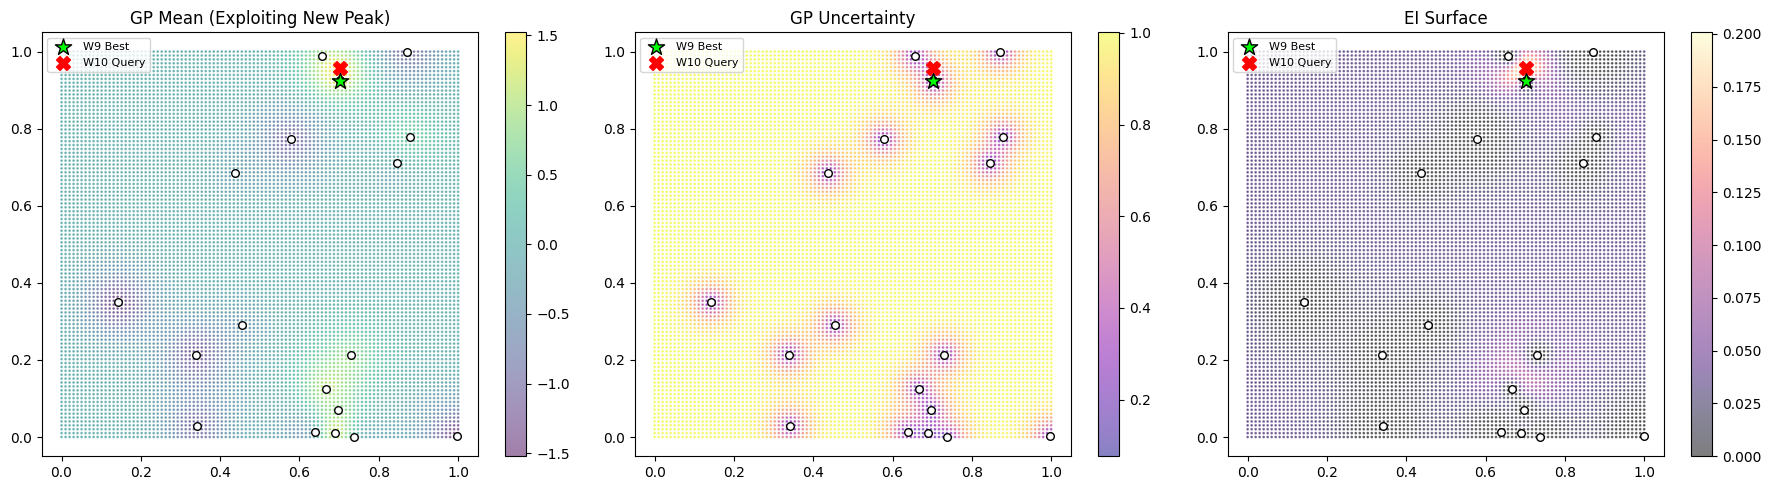

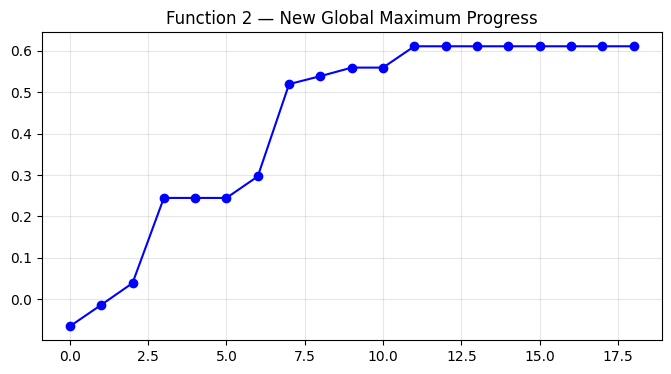

In [8]:
# Grid for surface plotting
x_plot = np.array(np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))).T.reshape(-1, 2)
mu_grid, sigma_grid = model.predict(x_plot, return_std=True)
ei_grid = expected_improvement(x_plot, model, y_max_trans)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['GP Mean (Exploiting New Peak)', 'GP Uncertainty', 'EI Surface']
surfaces = [mu_grid, sigma_grid, ei_grid.flatten()]
cmaps = ['viridis', 'plasma', 'magma']

for ax, surface, title, cmap in zip(axes, surfaces, titles, cmaps):
    sc = ax.scatter(x_plot[:, 0], x_plot[:, 1], c=surface, cmap=cmap, s=1, alpha=0.5)
    ax.scatter(X_unique[:, 0], X_unique[:, 1], c='white', edgecolors='black', s=30)
    ax.scatter(X_w9_best[0], X_w9_best[1], c='lime', marker='*', s=150, edgecolors='black', label='W9 Best')
    ax.scatter(next_query[0], next_query[1], c='red', marker='X', s=100, label='W10 Query')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Progress plot
plt.figure(figsize=(8, 4))
plt.plot(np.maximum.accumulate(Y_updated), marker='o', color='blue')
plt.title('Function 2 — New Global Maximum Progress')
plt.grid(True, alpha=0.3)
plt.show()